# EIA Petroleum Lead-Lag Analysis — Debugged Testing Notebook

This version fixes the broken date parsing that produced year `0001` dates.

### Main fixes
- Uses official EIA `hist_xls` files first instead of trusting the API response blindly.
- Adds strict date validation: years before 1980 are rejected.
- Keeps a safe HTML fallback that reconstructs missing years from the `Year-Month` row.
- Adds `OFFLINE_TEST_MODE` so the whole notebook can be tested without internet.
- Adds an export cell that creates a downloadable ZIP bundle with CSV outputs.

**Caveman meaning:**  
stock level = warehouse pile size  
weekly change = pile up/down this week  
lead-lag = who moves first, who follows later


In [1]:


# CELL 1 — Runtime setup

from datetime import datetime, timezone
import sys
import subprocess
import warnings
warnings.filterwarnings("ignore")

RUN_DATE = datetime.now(timezone.utc)
print(f"Notebook run date : {RUN_DATE:%Y-%m-%d}")
print(f"Run timestamp     : {RUN_DATE:%Y-%m-%d %H:%M:%S %Z}")

# Install only if packages are missing.
REQUIRED_PACKAGES = [
    "pandas", "numpy", "matplotlib", "requests",
    "beautifulsoup4", "lxml", "html5lib", "openpyxl",
    "xlrd", "statsmodels", "scikit-learn"
]

def ensure_packages(packages):
    missing = []
    for pkg in packages:
        import_name = {
            "beautifulsoup4": "bs4",
            "scikit-learn": "sklearn",
            "xlrd": "xlrd",
        }.get(pkg, pkg)
        try:
            __import__(import_name)
        except Exception:
            missing.append(pkg)

    if missing:
        print("Installing missing packages:", missing)
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    else:
        print("All required packages already available.")

ensure_packages(REQUIRED_PACKAGES)


Notebook run date : 2026-04-27
Run timestamp     : 2026-04-27 12:37:40 UTC
Installing missing packages: ['lxml']


In [2]:

# ============================================================
# CELL 2 — Imports
# ============================================================
import io
import os
import re
import time
import json
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)


from statsmodels.tsa.stattools import grangercausalitytests
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

print("Imports OK.")


Imports OK.


In [3]:

# ============================================================
# CELL 3 — Config
# ============================================================
# Set to True only when you want to test the notebook logic without internet.
OFFLINE_TEST_MODE = False

# If live fetch fails and this is True, notebook falls back to synthetic data.
# For real analysis, keep this False so failure is visible.
ALLOW_SYNTHETIC_FALLBACK = False

# Output folder used by export/download cell.
OUTPUT_DIR = Path("eia_testing_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SERIES = {
    "crude_commercial": {
        "series_id": "WCESTUS1",
        "label": "Crude Commercial",
        "hist_xls": "https://www.eia.gov/dnav/pet/hist_xls/WCESTUS1w.xls",
        "leaf": "https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?f=W&n=PET&s=WCESTUS1",
    },
    "gasoline_total": {
        "series_id": "WGTSTUS1",
        "label": "Gasoline Total",
        "hist_xls": "https://www.eia.gov/dnav/pet/hist_xls/WGTSTUS1w.xls",
        "leaf": "https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?f=W&n=PET&s=WGTSTUS1",
    },
    "distillate_total": {
        "series_id": "WDISTUS1",
        "label": "Distillate Total",
        "hist_xls": "https://www.eia.gov/dnav/pet/hist_xls/WDISTUS1w.xls",
        "leaf": "https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?f=W&n=PET&s=WDISTUS1",
    },
    "cushing": {
        "series_id": "W_EPC0_SAX_YCUOK_MBBL",
        "label": "Cushing Crude",
        "hist_xls": "https://www.eia.gov/dnav/pet/hist_xls/W_EPC0_SAX_YCUOK_MBBLw.xls",
        "leaf": "https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?f=W&n=PET&s=W_EPC0_SAX_YCUOK_MBBL",
    },
}

MIN_VALID_YEAR = 1980
MAX_FUTURE_DAYS_ALLOWED = 14

print("Series configured:")
for key, meta in SERIES.items():
    print(f"- {key}: {meta['series_id']} -> {meta['label']}")


Series configured:
- crude_commercial: WCESTUS1 -> Crude Commercial
- gasoline_total: WGTSTUS1 -> Gasoline Total
- distillate_total: WDISTUS1 -> Distillate Total
- cushing: W_EPC0_SAX_YCUOK_MBBL -> Cushing Crude


In [4]:

# ============================================================
# CELL 4 — Robust EIA fetcher with strict date validation
# ============================================================

def _clean_number(x):
    """Convert EIA value strings like '338,764' into float."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    s = re.sub(r"[^0-9.\-]", "", s)
    if s == "":
        return np.nan
    return pd.to_numeric(s, errors="coerce")


def _validate_eia_frame(df: pd.DataFrame, series_id: str, min_rows: int = 100) -> pd.DataFrame:
    """
    Enforce sane EIA dates.

    This is the key repair:
    the previous notebook accepted parsed dates like 0001-12-31.
    This validator rejects that immediately before analysis.
    """
    out = df.copy()
    out["date"] = pd.to_datetime(out["date"], errors="coerce")
    out["value"] = pd.to_numeric(out["value"], errors="coerce")
    out = (
        out[["date", "value"]]
        .dropna(subset=["date", "value"])
        .drop_duplicates(subset="date")
        .sort_values("date")
        .reset_index(drop=True)
    )

    if len(out) < min_rows:
        raise RuntimeError(f"{series_id}: too few usable rows after parsing ({len(out)})")

    min_year = int(out["date"].dt.year.min())
    max_date = out["date"].max()
    today = pd.Timestamp.utcnow().tz_localize(None).normalize()

    if min_year < MIN_VALID_YEAR:
        bad_preview = out.head(5).to_string(index=False)
        raise RuntimeError(
            f"{series_id}: invalid parsed year detected ({min_year}).\n"
            f"This usually means HTML dates like 12/31 were parsed without a year.\n"
            f"Preview:\n{bad_preview}"
        )

    if max_date > today + pd.Timedelta(days=MAX_FUTURE_DAYS_ALLOWED):
        raise RuntimeError(f"{series_id}: latest date is unrealistically in the future: {max_date.date()}")

    return out


def fetch_from_hist_xls(series_id: str, url: str, timeout: int = 45) -> pd.DataFrame:
    """
    Preferred source: EIA official 'Download Data (XLS File)' endpoint.
    Expected layout:
    row 1: title
    row 2: Sourcekey
    row 3: Date, value-column-name
    row 4+: data
    """
    resp = requests.get(url, timeout=timeout)
    resp.raise_for_status()

    raw = pd.read_excel(io.BytesIO(resp.content), header=None, engine=None)

    # Find the header row where first column is "Date".
    first_col = raw.iloc[:, 0].astype(str).str.strip().str.lower()
    matches = np.where(first_col.eq("date"))[0]
    if len(matches) == 0:
        raise RuntimeError(f"{series_id}: could not find Date header in XLS")

    header_row = int(matches[0])
    data = raw.iloc[header_row + 1:, :2].copy()
    data.columns = ["date", "value"]
    data = data.dropna(how="all")

    return _validate_eia_frame(data, series_id=series_id)


def _parse_year_month_label(x):
    """
    Parse labels such as '1982-Aug', '1982 Aug', or '1982-August'.
    Returns integer year or None.
    """
    s = str(x)
    m = re.search(r"(\d{4})\s*[- ]\s*([A-Za-z]{3,9})", s)
    if not m:
        return None
    return int(m.group(1))


def fetch_from_leaf_html(series_id: str, url: str, timeout: int = 45) -> pd.DataFrame:
    """
    Safe fallback for EIA LeafHandler HTML.

    Important repair:
    EIA table cells may show dates as MM/DD without year.
    We reconstruct the year from the Year-Month row instead of letting pandas
    parse them as year 0001.
    """
    resp = requests.get(url, timeout=timeout)
    resp.raise_for_status()
    html = resp.text

    tables = pd.read_html(io.StringIO(html))
    rows = []

    for table in tables:
        if table.empty:
            continue

        for _, row in table.iterrows():
            vals = [None if pd.isna(v) else str(v).strip() for v in row.tolist()]
            year = _parse_year_month_label(vals[0]) if vals else None
            if year is None:
                continue

            # Values appear as pairs: date, value, date, value...
            for i in range(1, len(vals) - 1, 2):
                date_txt = vals[i]
                val_txt = vals[i + 1]
                if not date_txt or not val_txt:
                    continue

                # Supported: MM/DD or MM/DD/YYYY
                if re.fullmatch(r"\d{1,2}/\d{1,2}", date_txt):
                    dt = pd.to_datetime(f"{date_txt}/{year}", format="%m/%d/%Y", errors="coerce")
                elif re.fullmatch(r"\d{1,2}/\d{1,2}/\d{4}", date_txt):
                    dt = pd.to_datetime(date_txt, format="%m/%d/%Y", errors="coerce")
                else:
                    continue

                val = _clean_number(val_txt)
                if pd.notna(dt) and pd.notna(val):
                    rows.append((dt, val))

    if not rows:
        # Last attempt: parse exact MM/DD/YYYY patterns from raw text.
        soup = BeautifulSoup(html, "html.parser")
        text = soup.get_text(" ", strip=True)
        pairs = re.findall(r"(\d{1,2}/\d{1,2}/\d{4})\s+([0-9,]+(?:\.\d+)?)", text)
        rows = [(pd.to_datetime(d, format="%m/%d/%Y", errors="coerce"), _clean_number(v)) for d, v in pairs]

    if not rows:
        raise RuntimeError(f"{series_id}: HTML fallback could not extract rows")

    data = pd.DataFrame(rows, columns=["date", "value"])
    return _validate_eia_frame(data, series_id=series_id)


def make_synthetic_eia_series(start="2015-01-02", periods=520, seed=42):
    """
    Offline-only test data. Not for real analysis.
    Creates EIA-like weekly inventory levels so the rest of the notebook can be tested.
    """
    rng = np.random.default_rng(seed)
    dates = pd.date_range(start=start, periods=periods, freq="W-FRI")

    base = {
        "Crude Commercial": 450_000,
        "Gasoline Total": 230_000,
        "Distillate Total": 130_000,
        "Cushing Crude": 45_000,
    }

    out = {}
    for idx, (label, level) in enumerate(base.items()):
        seasonal = 5_000 * np.sin(np.linspace(0, 12 * np.pi, periods) + idx)
        noise = rng.normal(0, 2_500, periods).cumsum()
        out[label] = level + seasonal + noise

    return pd.DataFrame(out, index=dates).round(0)


def fetch_eia_series(series_id: str, hist_xls_url: str, leaf_url: str, timeout: int = 45) -> pd.DataFrame:
    """
    Fetch one EIA series using robust official paths.
    Priority:
    1) hist_xls download file
    2) LeafHandler HTML fallback
    """
    errors = []

    try:
        df = fetch_from_hist_xls(series_id, hist_xls_url, timeout=timeout)
        print(f"  [{series_id}] hist_xls OK — {len(df):,} rows | {df['date'].min().date()} -> {df['date'].max().date()}")
        return df
    except Exception as e:
        errors.append(f"hist_xls: {e}")
        print(f"  [{series_id}] hist_xls failed: {e}")

    try:
        df = fetch_from_leaf_html(series_id, leaf_url, timeout=timeout)
        print(f"  [{series_id}] HTML fallback OK — {len(df):,} rows | {df['date'].min().date()} -> {df['date'].max().date()}")
        return df
    except Exception as e:
        errors.append(f"html: {e}")
        print(f"  [{series_id}] HTML fallback failed: {e}")

    joined = "\n".join(errors)
    raise RuntimeError(f"All fetch strategies failed for {series_id}:\n{joined}")


print("Fetcher functions loaded.")


Fetcher functions loaded.


In [5]:

# ============================================================
# CELL 5 — Fetch/build common_levels and common_changes
# ============================================================

if OFFLINE_TEST_MODE:
    print("OFFLINE_TEST_MODE=True — using synthetic test data only.")
    common_levels = make_synthetic_eia_series()
    common_changes = common_levels.diff().dropna()
    long_df = (
        common_levels.reset_index(names="date")
        .melt(id_vars="date", var_name="series_name", value_name="value")
    )
else:
    all_series = []

    try:
        for key, meta in SERIES.items():
            tmp = fetch_eia_series(
                series_id=meta["series_id"],
                hist_xls_url=meta["hist_xls"],
                leaf_url=meta["leaf"],
                timeout=45
            ).copy()

            tmp["series_key"] = key
            tmp["series_name"] = meta["label"]
            all_series.append(tmp)

        long_df = pd.concat(all_series, ignore_index=True)

        # Remove duplicate date/series rows before pivot.
        long_df = (
            long_df.sort_values(["series_name", "date"])
                   .groupby(["date", "series_name"], as_index=False)["value"]
                   .last()
        )

        wide_levels = (
            long_df.pivot_table(
                index="date",
                columns="series_name",
                values="value",
                aggfunc="last"
            )
            .sort_index()
        )

        common_levels = wide_levels.dropna().copy()
        common_changes = common_levels.diff().dropna().copy()

    except Exception as e:
        if ALLOW_SYNTHETIC_FALLBACK:
            print("LIVE FETCH FAILED. Falling back to synthetic test data because ALLOW_SYNTHETIC_FALLBACK=True.")
            print("Error:", e)
            common_levels = make_synthetic_eia_series()
            common_changes = common_levels.diff().dropna()
            long_df = (
                common_levels.reset_index(names="date")
                .melt(id_vars="date", var_name="series_name", value_name="value")
            )
        else:
            raise

# Final safety validation.
common_levels.index = pd.to_datetime(common_levels.index, errors="coerce")
common_changes.index = pd.to_datetime(common_changes.index, errors="coerce")
common_levels = common_levels.loc[common_levels.index.notna()].sort_index()
common_changes = common_changes.loc[common_changes.index.notna()].sort_index()

if common_levels.index.min().year < MIN_VALID_YEAR:
    raise RuntimeError(
        f"BAD DATE PARSE: earliest date is {common_levels.index.min().date()}. "
        "Stop here and fix fetcher before analysis."
    )

print("\nLevels shape :", common_levels.shape)
print("Changes shape:", common_changes.shape)
print("Date range   :", common_levels.index.min().date(), "to", common_levels.index.max().date())

today = pd.Timestamp.utcnow().tz_localize(None).normalize()
data_lag_days = int((today - common_levels.index.max()).days)
print("Data lag vs today:", data_lag_days, "calendar day(s)")
if data_lag_days > 14 and not OFFLINE_TEST_MODE:
    print("WARNING: latest EIA data looks older than expected. Check EIA release timing or network cache.")

display(common_levels.tail())
display(common_changes.tail())


  [WCESTUS1] hist_xls failed: WCESTUS1: could not find Date header in XLS
  [WCESTUS1] HTML fallback OK — 2,273 rows | 1982-08-20 -> 2026-04-17
  [WGTSTUS1] hist_xls failed: WGTSTUS1: could not find Date header in XLS
  [WGTSTUS1] HTML fallback OK — 1,894 rows | 1990-01-05 -> 2026-04-17
  [WDISTUS1] hist_xls failed: WDISTUS1: could not find Date header in XLS
  [WDISTUS1] HTML fallback OK — 2,273 rows | 1982-08-20 -> 2026-04-17
  [W_EPC0_SAX_YCUOK_MBBL] hist_xls failed: W_EPC0_SAX_YCUOK_MBBL: could not find Date header in XLS
  [W_EPC0_SAX_YCUOK_MBBL] HTML fallback OK — 1,150 rows | 2004-04-09 -> 2026-04-17

Levels shape : (1150, 4)
Changes shape: (1149, 4)
Date range   : 2004-04-09 to 2026-04-17
Data lag vs today: 10 calendar day(s)


series_name,Crude Commercial,Cushing Crude,Distillate Total,Gasoline Total
date,,,,
2026-03-20,456185.0,30945.0,119936.0,241447.0
2026-03-27,461636.0,31465.0,117825.0,240861.0
2026-04-03,464717.0,31489.0,114681.0,239272.0
2026-04-10,463804.0,29762.0,111559.0,232944.0
2026-04-17,465729.0,30568.0,108132.0,228374.0


series_name,Crude Commercial,Cushing Crude,Distillate Total,Gasoline Total
date,,,,
2026-03-20,6926.0,3421.0,3032.0,-2593.0
2026-03-27,5451.0,520.0,-2111.0,-586.0
2026-04-03,3081.0,24.0,-3144.0,-1589.0
2026-04-10,-913.0,-1727.0,-3122.0,-6328.0
2026-04-17,1925.0,806.0,-3427.0,-4570.0


In [6]:

# ============================================================
# CELL 6 — Save raw levels/changes immediately for testing
# ============================================================
levels_csv = OUTPUT_DIR / "eia_common_levels.csv"
changes_csv = OUTPUT_DIR / "eia_common_changes.csv"
long_csv = OUTPUT_DIR / "eia_long_raw.csv"

common_levels.to_csv(levels_csv, index=True)
common_changes.to_csv(changes_csv, index=True)
long_df.to_csv(long_csv, index=False)

print("Saved:")
print("-", levels_csv)
print("-", changes_csv)
print("-", long_csv)


Saved:
- eia_testing_outputs\eia_common_levels.csv
- eia_testing_outputs\eia_common_changes.csv
- eia_testing_outputs\eia_long_raw.csv


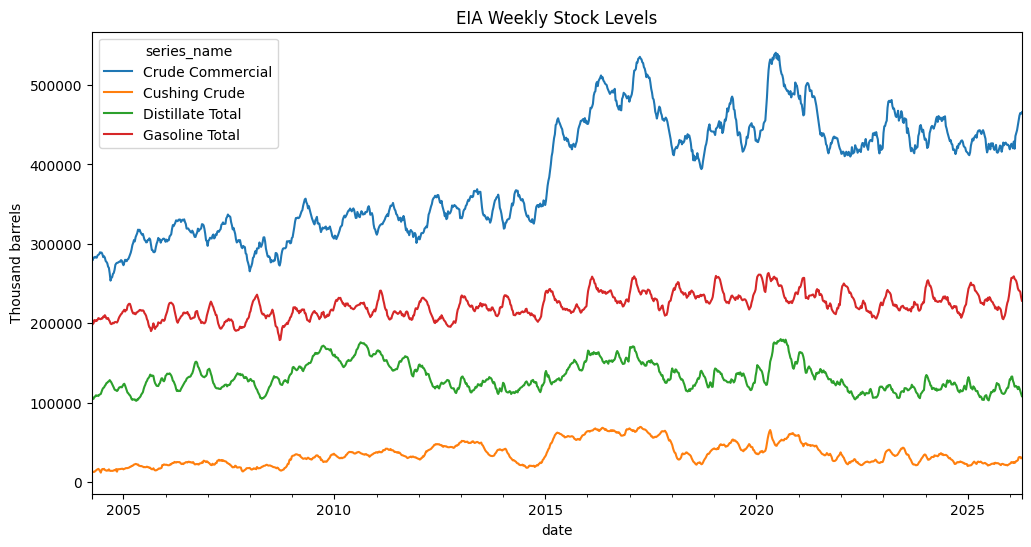

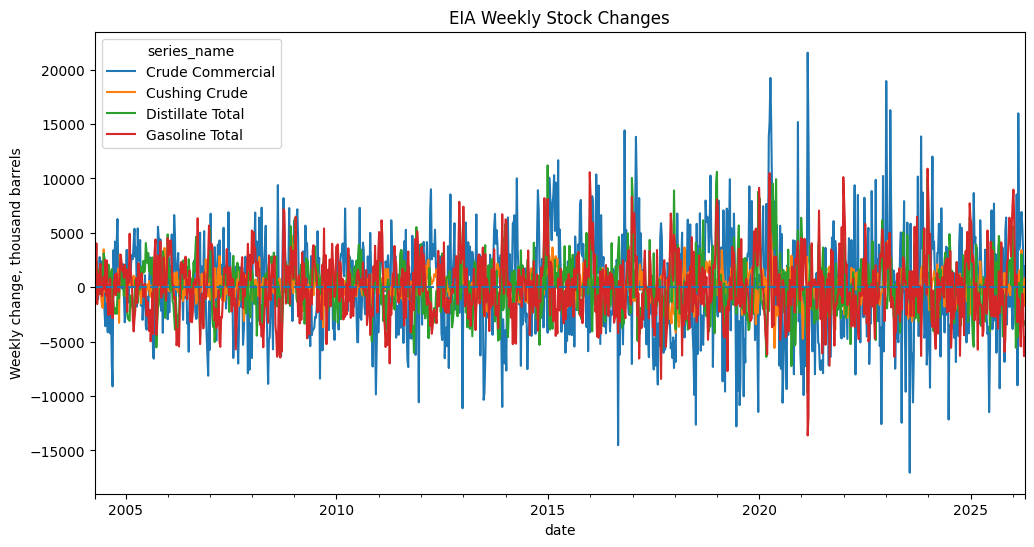

In [7]:

# ============================================================
# CELL 7 — Plot stock levels and weekly changes
# ============================================================
ax = common_levels.plot(title="EIA Weekly Stock Levels")
ax.set_ylabel("Thousand barrels")
plt.show()

ax = common_changes.plot(title="EIA Weekly Stock Changes")
ax.set_ylabel("Weekly change, thousand barrels")
plt.axhline(0, linestyle="--")
plt.show()


In [8]:

# ============================================================
# CELL 8 — Lead-lag correlation functions
# ============================================================
def lead_lag_corr(x: pd.Series, y: pd.Series, max_lag: int = 12) -> pd.DataFrame:
    """
    Positive lag means x leads y.
    Negative lag means y leads x.
    """
    rows = []
    df = pd.concat([x.rename("x"), y.rename("y")], axis=1).dropna()

    for lag in range(-max_lag, max_lag + 1):
        if lag > 0:
            xs = df["x"].iloc[:-lag]
            ys = df["y"].iloc[lag:]
        elif lag < 0:
            xs = df["x"].iloc[-lag:]
            ys = df["y"].iloc[:lag]
        else:
            xs = df["x"]
            ys = df["y"]

        corr = xs.corr(ys) if len(xs) >= 20 else np.nan
        rows.append({"lag_weeks": lag, "corr": corr})

    return pd.DataFrame(rows)


def best_lead_lag_table(data: pd.DataFrame, max_lag: int = 12) -> pd.DataFrame:
    cols = list(data.columns)
    out_rows = []

    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            a, b = cols[i], cols[j]
            cdf = lead_lag_corr(data[a], data[b], max_lag=max_lag).dropna()
            if cdf.empty:
                continue

            idx = cdf["corr"].abs().idxmax()
            row = cdf.loc[idx]
            lag = int(row["lag_weeks"])
            corr = float(row["corr"])

            if lag > 0:
                interp = f"{a} leads {b} by {lag} week(s)"
            elif lag < 0:
                interp = f"{b} leads {a} by {abs(lag)} week(s)"
            else:
                interp = f"{a} and {b} move most together in same week"

            out_rows.append({
                "series_a": a,
                "series_b": b,
                "best_lag_weeks": lag,
                "best_corr": corr,
                "interpretation": interp,
            })

    out = pd.DataFrame(out_rows)
    if out.empty:
        return out
    return out.sort_values("best_corr", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)


pair_table = best_lead_lag_table(common_changes, max_lag=12)
display(pair_table)
pair_table.to_csv(OUTPUT_DIR / "lead_lag_pair_table.csv", index=False)


,series_a,series_b,best_lag_weeks,best_corr,interpretation
0,Distillate Total,Gasoline Total,0,0.420477,Distillate Total and Gasoline Total move most ...
1,Crude Commercial,Cushing Crude,0,0.273770,Crude Commercial and Cushing Crude move most t...
2,Crude Commercial,Distillate Total,-12,-0.207859,Distillate Total leads Crude Commercial by 12 ...
3,Crude Commercial,Gasoline Total,-2,-0.106560,Gasoline Total leads Crude Commercial by 2 wee...
4,Cushing Crude,Distillate Total,-12,-0.059381,Distillate Total leads Cushing Crude by 12 wee...
5,Cushing Crude,Gasoline Total,-9,0.003244,Gasoline Total leads Cushing Crude by 9 week(s)


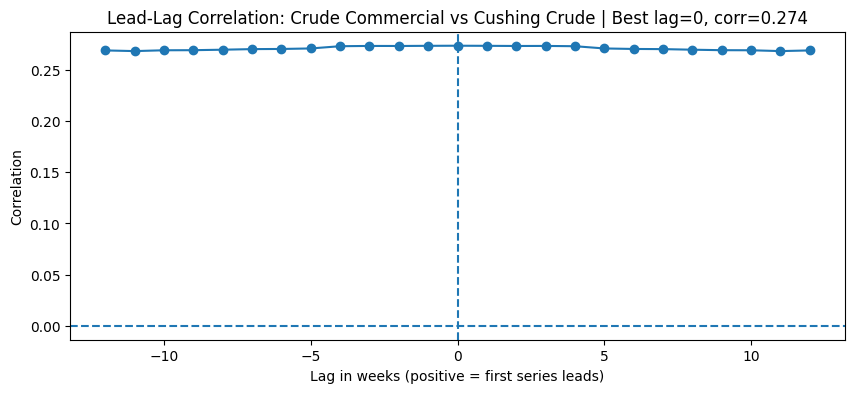

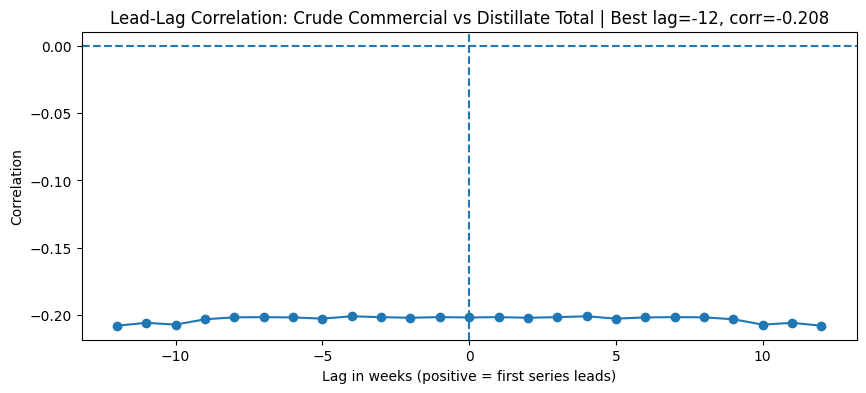

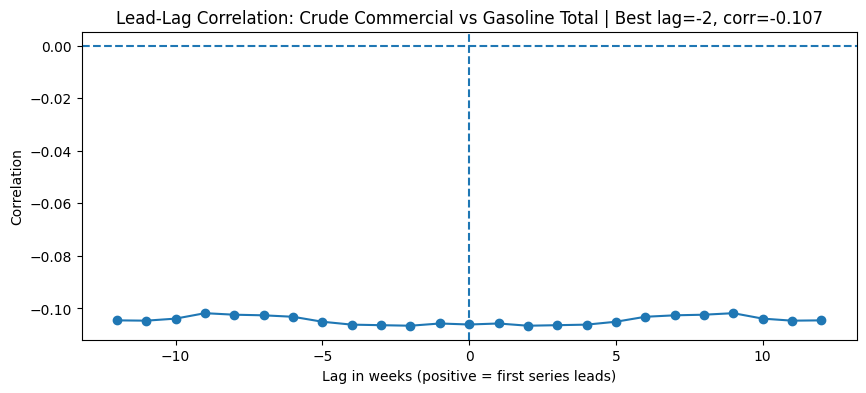

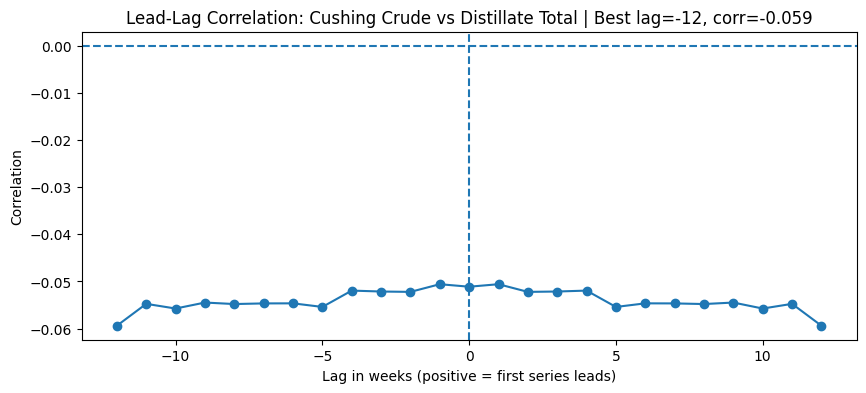

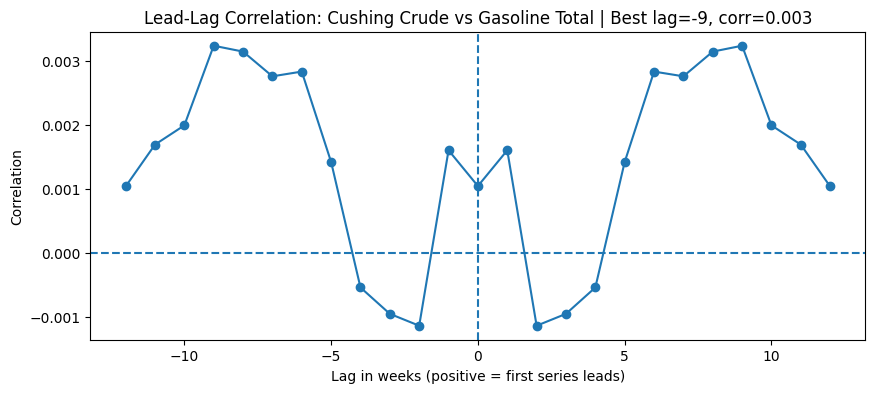

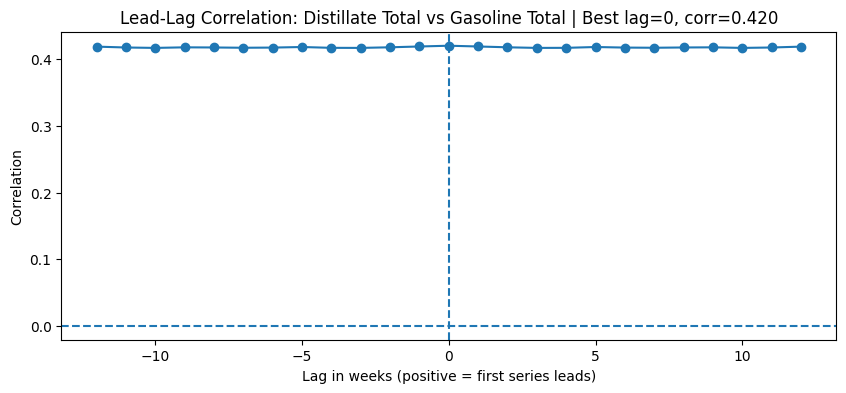

In [9]:

# ============================================================
# CELL 9 — Lead-lag plots
# ============================================================
cols = list(common_changes.columns)

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        a, b = cols[i], cols[j]
        cdf = lead_lag_corr(common_changes[a], common_changes[b], max_lag=12).dropna()
        if cdf.empty:
            continue

        best = cdf.loc[cdf["corr"].abs().idxmax()]

        plt.figure(figsize=(10, 4))
        plt.plot(cdf["lag_weeks"], cdf["corr"], marker="o")
        plt.axhline(0, linestyle="--")
        plt.axvline(0, linestyle="--")
        plt.title(f"Lead-Lag Correlation: {a} vs {b} | Best lag={int(best['lag_weeks'])}, corr={best['corr']:.3f}")
        plt.xlabel("Lag in weeks (positive = first series leads)")
        plt.ylabel("Correlation")
        plt.show()


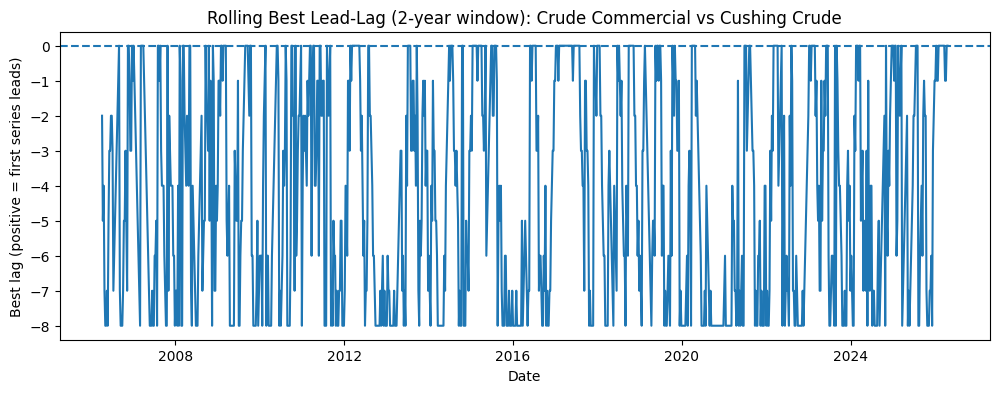

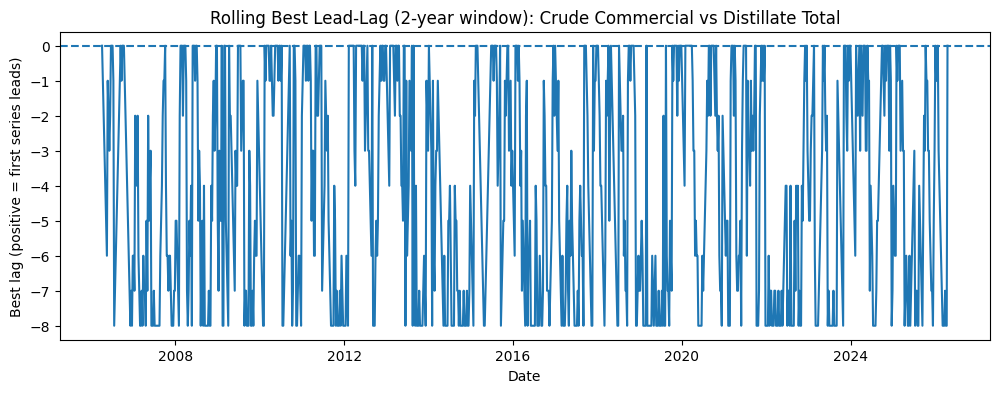

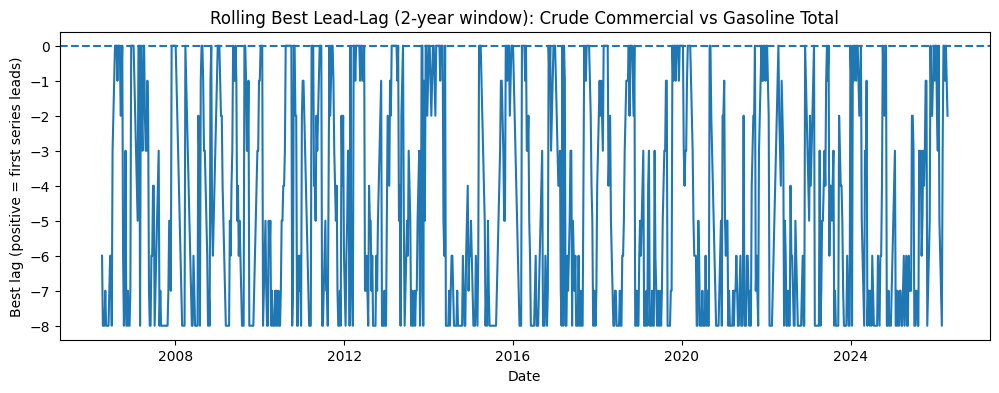

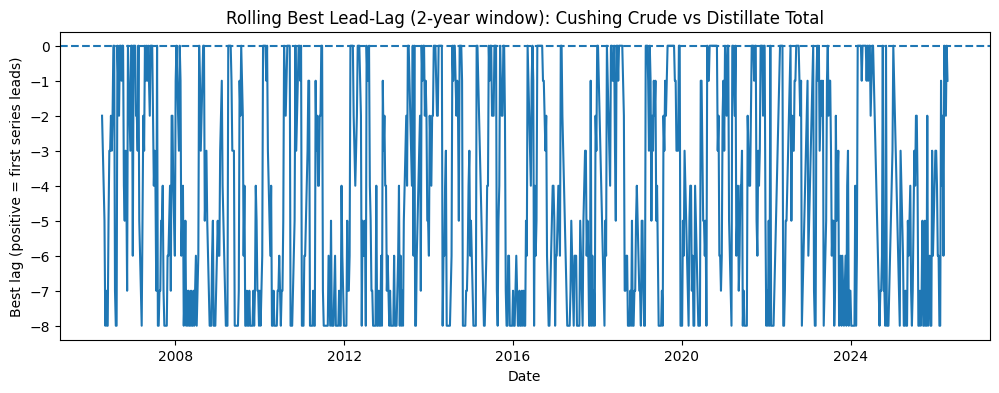

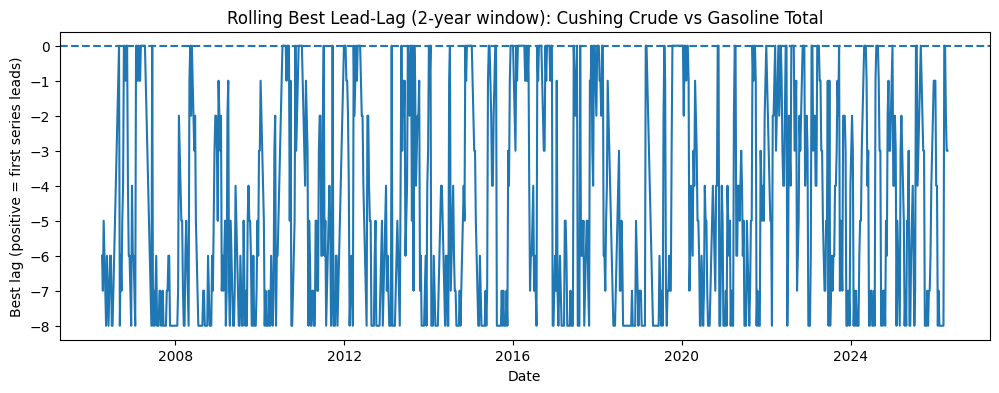

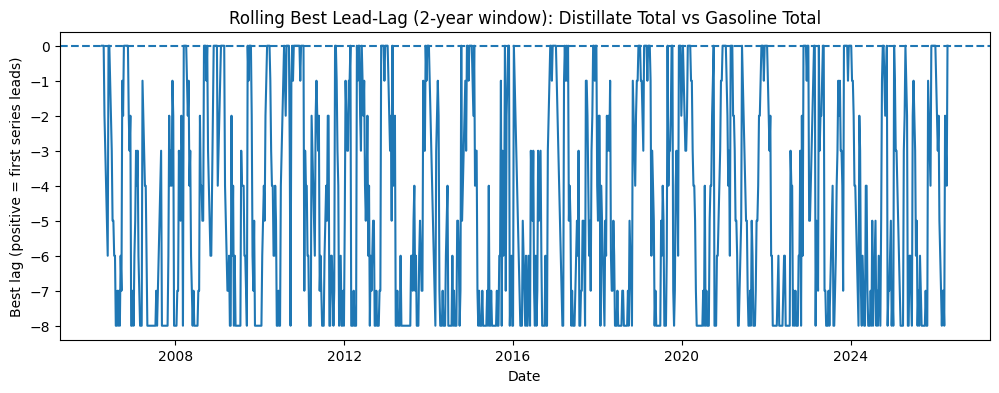

,date,best_lag,best_corr,series_a,series_b
6271,2026-03-20,-8,0.478713,Distillate Total,Gasoline Total
6272,2026-03-27,-2,0.472145,Distillate Total,Gasoline Total
6273,2026-04-03,-3,0.474966,Distillate Total,Gasoline Total
6274,2026-04-10,-4,0.474731,Distillate Total,Gasoline Total
6275,2026-04-17,0,0.482032,Distillate Total,Gasoline Total


In [10]:

# ============================================================
# CELL 10 — Rolling lead-lag
# ============================================================
def rolling_best_lag(x: pd.Series, y: pd.Series, window: int = 104, max_lag: int = 8) -> pd.DataFrame:
    joined = pd.concat([x.rename("x"), y.rename("y")], axis=1).dropna().copy()
    rows = []

    for end in range(window, len(joined) + 1):
        sub = joined.iloc[end - window:end]
        best_lag = np.nan
        best_corr = np.nan

        for lag in range(-max_lag, max_lag + 1):
            if lag > 0:
                xs = sub["x"].iloc[:-lag]
                ys = sub["y"].iloc[lag:]
            elif lag < 0:
                xs = sub["x"].iloc[-lag:]
                ys = sub["y"].iloc[:lag]
            else:
                xs = sub["x"]
                ys = sub["y"]

            if len(xs) < 20:
                continue

            corr = xs.corr(ys)
            if pd.isna(corr):
                continue

            if pd.isna(best_corr) or abs(corr) > abs(best_corr):
                best_corr = corr
                best_lag = lag

        rows.append({
            "date": sub.index[-1],
            "best_lag": best_lag,
            "best_corr": best_corr,
        })

    return pd.DataFrame(rows)


rolling_outputs = []
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        a, b = cols[i], cols[j]
        roll = rolling_best_lag(common_changes[a], common_changes[b], window=104, max_lag=8)
        if roll.empty:
            continue

        roll["series_a"] = a
        roll["series_b"] = b
        rolling_outputs.append(roll)

        plt.figure(figsize=(12, 4))
        plt.plot(roll["date"], roll["best_lag"])
        plt.axhline(0, linestyle="--")
        plt.title(f"Rolling Best Lead-Lag (2-year window): {a} vs {b}")
        plt.ylabel("Best lag (positive = first series leads)")
        plt.xlabel("Date")
        plt.show()

rolling_lag_table = pd.concat(rolling_outputs, ignore_index=True) if rolling_outputs else pd.DataFrame()
if not rolling_lag_table.empty:
    rolling_lag_table.to_csv(OUTPUT_DIR / "rolling_lead_lag_table.csv", index=False)

display(rolling_lag_table.tail())


In [11]:

# ============================================================
# CELL 11 — Granger causality summary
# ============================================================
def granger_summary(df: pd.DataFrame, maxlag: int = 8, verbose: bool = False) -> pd.DataFrame:
    cols = list(df.columns)
    rows = []

    for cause in cols:
        for effect in cols:
            if cause == effect:
                continue

            tmp = df[[effect, cause]].dropna().copy()
            if len(tmp) < max(60, maxlag * 10):
                rows.append({
                    "cause": cause,
                    "effect": effect,
                    "best_test_lag": np.nan,
                    "best_pvalue": np.nan,
                    "significant_5pct": False,
                    "error": "not enough rows",
                })
                continue

            try:
                result = grangercausalitytests(tmp, maxlag=maxlag, verbose=verbose)
                pvals = []
                for lag in range(1, maxlag + 1):
                    pval = result[lag][0]["ssr_ftest"][1]
                    pvals.append((lag, pval))

                best_lag, best_p = min(pvals, key=lambda z: z[1])
                rows.append({
                    "cause": cause,
                    "effect": effect,
                    "best_test_lag": best_lag,
                    "best_pvalue": best_p,
                    "significant_5pct": best_p < 0.05,
                    "error": "",
                })
            except Exception as e:
                rows.append({
                    "cause": cause,
                    "effect": effect,
                    "best_test_lag": np.nan,
                    "best_pvalue": np.nan,
                    "significant_5pct": False,
                    "error": str(e),
                })

    out = pd.DataFrame(rows)
    return out.sort_values(["significant_5pct", "best_pvalue"], ascending=[False, True]).reset_index(drop=True)


granger_tbl = granger_summary(common_changes, maxlag=8, verbose=False)
display(granger_tbl)
granger_tbl.to_csv(OUTPUT_DIR / "granger_summary.csv", index=False)


,cause,effect,best_test_lag,best_pvalue,significant_5pct,error
0,Distillate Total,Gasoline Total,8,8.654487e-07,True,
1,Crude Commercial,Cushing Crude,3,1.840318e-06,True,
2,Distillate Total,Cushing Crude,4,2.051036e-05,True,
3,Cushing Crude,Crude Commercial,1,1.270653e-04,True,
4,Distillate Total,Crude Commercial,1,1.288089e-04,True,
5,Crude Commercial,Gasoline Total,1,1.268955e-02,True,
6,Gasoline Total,Crude Commercial,8,1.559087e-02,True,
7,Cushing Crude,Distillate Total,5,1.630945e-02,True,
8,Crude Commercial,Distillate Total,1,2.100307e-02,True,
9,Cushing Crude,Gasoline Total,4,9.995864e-02,False,


In [12]:

# ============================================================
# CELL 12 — Recent 5-year view
# ============================================================
YEARS_BACK = 5
data_max_dt = common_changes.index.max()
cutoff = data_max_dt - pd.DateOffset(years=YEARS_BACK)

recent_changes = common_changes.loc[common_changes.index >= cutoff].copy()

print(f"Recent sample : {recent_changes.index.min().date()} -> {recent_changes.index.max().date()}")
print(f"Rows          : {len(recent_changes)}")

recent_pair_table = best_lead_lag_table(recent_changes, max_lag=12)
recent_granger_tbl = granger_summary(recent_changes, maxlag=8, verbose=False)

display(recent_pair_table)
display(recent_granger_tbl)

recent_pair_table.to_csv(OUTPUT_DIR / "recent_lead_lag_pair_table.csv", index=False)
recent_granger_tbl.to_csv(OUTPUT_DIR / "recent_granger_summary.csv", index=False)


Recent sample : 2021-04-23 -> 2026-04-17
Rows          : 261


,series_a,series_b,best_lag_weeks,best_corr,interpretation
0,Distillate Total,Gasoline Total,-12,0.494126,Gasoline Total leads Distillate Total by 12 we...
1,Crude Commercial,Cushing Crude,-3,0.271844,Cushing Crude leads Crude Commercial by 3 week(s)
2,Crude Commercial,Distillate Total,-10,-0.159342,Distillate Total leads Crude Commercial by 10 ...
3,Crude Commercial,Gasoline Total,0,-0.080424,Crude Commercial and Gasoline Total move most ...
4,Cushing Crude,Gasoline Total,-8,0.057746,Gasoline Total leads Cushing Crude by 8 week(s)
5,Cushing Crude,Distillate Total,-1,0.056043,Distillate Total leads Cushing Crude by 1 week(s)


,cause,effect,best_test_lag,best_pvalue,significant_5pct,error
0,Distillate Total,Gasoline Total,1,0.000438,True,
1,Crude Commercial,Cushing Crude,6,0.001283,True,
2,Distillate Total,Crude Commercial,1,0.013511,True,
3,Distillate Total,Cushing Crude,2,0.026098,True,
4,Cushing Crude,Crude Commercial,1,0.035668,True,
5,Crude Commercial,Gasoline Total,1,0.072742,False,
6,Gasoline Total,Crude Commercial,6,0.075059,False,
7,Cushing Crude,Distillate Total,8,0.085275,False,
8,Crude Commercial,Distillate Total,1,0.233044,False,
9,Cushing Crude,Gasoline Total,1,0.292733,False,


In [13]:

# ============================================================
# CELL 13 — Leakage-safe classifier feature test
# ============================================================
# Predict future direction of TARGET_COL using lagged inventory-change features only.
# No current/future target leakage:
# - features are shifted by at least 1 week
# - target is shifted forward by HORIZON_WEEKS
# - walk-forward trains only on past rows

TARGET_COL = "Crude Commercial"
HORIZON_WEEKS = 1
MAX_FEATURE_LAG = 4
ROLL_Z_WINDOW = 26
TRAIN_MIN = 80
RETRAIN_EVERY = 4
THRESHOLD_PROBA = 0.50
YEARS_BACK = 10

df0 = common_changes.copy()
df0 = df0.apply(pd.to_numeric, errors="coerce").dropna(how="all")
df0 = df0.loc[df0.index >= df0.index.max() - pd.DateOffset(years=YEARS_BACK)].copy()

if TARGET_COL not in df0.columns:
    raise ValueError(f"TARGET_COL not found: {TARGET_COL}")

# Build lagged features.
feat = pd.DataFrame(index=df0.index)

for col in df0.columns:
    s = pd.to_numeric(df0[col], errors="coerce")

    for lag in range(1, MAX_FEATURE_LAG + 1):
        feat[f"{col}_chg_lag{lag}"] = s.shift(lag)
        feat[f"{col}_abs_chg_lag{lag}"] = s.abs().shift(lag)

    # rolling z-score uses only past data through shift(1)
    past = s.shift(1)
    roll_mean = past.rolling(ROLL_Z_WINDOW, min_periods=ROLL_Z_WINDOW).mean()
    roll_std = past.rolling(ROLL_Z_WINDOW, min_periods=ROLL_Z_WINDOW).std().replace(0, np.nan)
    feat[f"{col}_rolling_z_lag1"] = (past - roll_mean) / roll_std
    feat[f"{col}_rolling_std_lag1"] = roll_std

# Pair spread features, lagged.
for i in range(len(df0.columns)):
    for j in range(i + 1, len(df0.columns)):
        a, b = df0.columns[i], df0.columns[j]
        spread = df0[a] - df0[b]
        feat[f"spread_{a}_minus_{b}_lag1"] = spread.shift(1)

target_future_change = df0[TARGET_COL].shift(-HORIZON_WEEKS)
target_direction = (target_future_change > 0).astype(float)

model_df = feat.copy()
model_df["target_direction"] = target_direction
model_df["future_change"] = target_future_change
model_df = model_df.dropna(subset=["target_direction", "future_change"])

X_all = model_df.drop(columns=["target_direction", "future_change"])
y_all = model_df["target_direction"].astype(int)

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced")),
])

pred_rows = []
last_fit_i = None

for i in range(TRAIN_MIN, len(model_df)):
    # Refit periodically using only past data up to i-1.
    if last_fit_i is None or (i - last_fit_i) >= RETRAIN_EVERY:
        X_train = X_all.iloc[:i]
        y_train = y_all.iloc[:i]

        # Need both classes in training.
        if y_train.nunique() < 2:
            continue

        pipe.fit(X_train, y_train)
        last_fit_i = i

    X_test = X_all.iloc[[i]]
    y_true = int(y_all.iloc[i])
    proba_up = float(pipe.predict_proba(X_test)[0, 1])
    pred = int(proba_up >= THRESHOLD_PROBA)

    pred_rows.append({
        "date": model_df.index[i],
        "target_col": TARGET_COL,
        "horizon_weeks": HORIZON_WEEKS,
        "p_up": proba_up,
        "pred_direction": pred,
        "true_direction": y_true,
        "future_change": float(model_df["future_change"].iloc[i]),
        "correct": int(pred == y_true),
    })

pred_table = pd.DataFrame(pred_rows)

if pred_table.empty:
    raise RuntimeError("No predictions produced. Lower TRAIN_MIN or check input data.")

acc = accuracy_score(pred_table["true_direction"], pred_table["pred_direction"])
cm = confusion_matrix(pred_table["true_direction"], pred_table["pred_direction"])

print("=" * 80)
print("WALK-FORWARD CLASSIFIER TEST")
print("=" * 80)
print("Target:", TARGET_COL)
print("Rows tested:", len(pred_table))
print("Accuracy:", round(acc, 4))
print("Confusion matrix [[true_down, pred_down/up], [true_up, pred_down/up]]:")
print(cm)
print()
print(classification_report(pred_table["true_direction"], pred_table["pred_direction"], digits=4))

display(pred_table.tail(10))
pred_table.to_csv(OUTPUT_DIR / "walkforward_classifier_predictions.csv", index=False)

# Feature importance from final fitted logistic model.
feature_importance = pd.DataFrame({
    "feature": X_all.columns,
    "coefficient": pipe.named_steps["model"].coef_[0],
})
feature_importance["abs_coefficient"] = feature_importance["coefficient"].abs()
feature_importance = feature_importance.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

display(feature_importance.head(25))
feature_importance.to_csv(OUTPUT_DIR / "classifier_feature_importance.csv", index=False)


WALK-FORWARD CLASSIFIER TEST
Target: Crude Commercial
Rows tested: 441
Accuracy: 0.5465
Confusion matrix [[true_down, pred_down/up], [true_up, pred_down/up]]:
[[123 103]
 [ 97 118]]

              precision    recall  f1-score   support

           0     0.5591    0.5442    0.5516       226
           1     0.5339    0.5488    0.5413       215

    accuracy                         0.5465       441
   macro avg     0.5465    0.5465    0.5464       441
weighted avg     0.5468    0.5465    0.5466       441



,date,target_col,horizon_weeks,p_up,pred_direction,true_direction,future_change,correct
431,2026-02-06,Crude Commercial,1,0.673873,1,0,-9014.0,0
432,2026-02-13,Crude Commercial,1,0.626430,1,1,15989.0,1
433,2026-02-20,Crude Commercial,1,0.499992,0,1,3475.0,0
434,2026-02-27,Crude Commercial,1,0.841356,1,1,3824.0,1
435,2026-03-06,Crude Commercial,1,0.504711,1,1,6156.0,1
436,2026-03-13,Crude Commercial,1,0.806855,1,1,6926.0,1
437,2026-03-20,Crude Commercial,1,0.441458,0,1,5451.0,0
438,2026-03-27,Crude Commercial,1,0.598655,1,1,3081.0,1
439,2026-04-03,Crude Commercial,1,0.667738,1,0,-913.0,0
440,2026-04-10,Crude Commercial,1,0.407267,0,1,1925.0,0


,feature,coefficient,abs_coefficient
0,Gasoline Total_rolling_z_lag1,-1.013098,1.013098
1,Distillate Total_rolling_z_lag1,-0.533744,0.533744
2,Gasoline Total_chg_lag1,0.474171,0.474171
3,Cushing Crude_chg_lag1,0.359888,0.359888
4,Crude Commercial_rolling_z_lag1,-0.315903,0.315903
5,Distillate Total_chg_lag1,0.296349,0.296349
6,spread_Cushing Crude_minus_Gasoline Total_lag1,-0.284880,0.284880
7,Gasoline Total_rolling_std_lag1,-0.283740,0.283740
8,Crude Commercial_chg_lag1,0.239010,0.239010
9,Crude Commercial_abs_chg_lag1,0.227401,0.227401


In [14]:

# ============================================================
# CELL 14 — Latest live signal from latest available data
# ============================================================
# This is not a trading guarantee. It is only the model's latest directional
# probability for the next EIA weekly change of TARGET_COL.

latest_X = X_all.iloc[[-1]]
latest_date = X_all.index[-1]
latest_p_up = float(pipe.predict_proba(latest_X)[0, 1])
latest_p_down = 1.0 - latest_p_up

SIGNAL_THRESHOLD = 0.55
if latest_p_up >= SIGNAL_THRESHOLD:
    signal = "LONG / UP"
elif latest_p_up <= (1.0 - SIGNAL_THRESHOLD):
    signal = "SHORT / DOWN"
else:
    signal = "FLAT / UNCERTAIN"

latest_signal = pd.DataFrame([{
    "latest_feature_date_used": latest_date,
    "target_col": TARGET_COL,
    "horizon_weeks": HORIZON_WEEKS,
    "p_up": latest_p_up,
    "p_down": latest_p_down,
    "signal": signal,
}])

print("=" * 80)
print("LATEST SIGNAL")
print("=" * 80)
print(latest_signal.to_string(index=False))

latest_signal.to_csv(OUTPUT_DIR / "latest_signal.csv", index=False)
display(latest_signal)


LATEST SIGNAL
latest_feature_date_used       target_col  horizon_weeks     p_up   p_down       signal
              2026-04-10 Crude Commercial              1 0.407267 0.592733 SHORT / DOWN


,latest_feature_date_used,target_col,horizon_weeks,p_up,p_down,signal
0,2026-04-10,Crude Commercial,1,0.407267,0.592733,SHORT / DOWN
